In [6]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [7]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)

    
v2s=[]
v2strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 380:400"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v2s.append(sub)        
    v2strings.append(sub2)

In [8]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists


In [34]:

v1_dists = getPairwiseDists(systems,v1s,v1strings,stride = 1,EQPOINT=EQPOINT)

#save("allpcadists-V2-CApairwise.npy",dists)
#dists=load("allpcadists-V1-CApairwise.npy")

v1_shaped_dists=[]
v1_pca_colours = []
for i in range(len(v1_dists)):
    for j in range(len(v1_dists[i])):
        for k in range(len(v1_dists[i][j])):
            v1_shaped_dists.append(v1_dists[i][j][k])
            v1_pca_colours.append(colourScheme[i])
            
            

v1_Z=sklearn.preprocessing.StandardScaler().fit_transform(v1_shaped_dists)

v1_myPCA=sklearn.decomposition.PCA(n_components=2)
v1_myfit=v1_myPCA.fit(v1_Z)
v1_pcaX=v1_myPCA.transform(v1_Z)
v1_pcaPoints= v1_pcaX.T



#Create a scaler
v1_scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
v1_scaler.fit(v1_shaped_dists)
# get the mean and scale of this transformation
v1_scale_final = v1_scaler.scale_
v1_mean_final = v1_scaler.mean_


v1_scaled_dists = (copy(v1_dists) - v1_mean_final)/v1_scale_final
v1_transformed_dists = []
for i in range(len(v1_scaled_dists)):
    sub=[]
    for j in range(len(v1_scaled_dists[i])):
        sub.append(v1_myPCA.transform(v1_scaled_dists[i][j]))
        
    v1_transformed_dists.append(sub)

In [35]:

v2_dists = getPairwiseDists(systems,v2s,v2strings,stride = 1,EQPOINT=EQPOINT)

#save("allpcadists-V2-CApairwise.npy",dists)
#dists=load("allpcadists-v2-CApairwise.npy")

v2_shaped_dists=[]
v2_pca_colours = []
for i in range(len(v2_dists)):
    for j in range(len(v2_dists[i])):
        for k in range(len(v2_dists[i][j])):
            v2_shaped_dists.append(v2_dists[i][j][k])
            v2_pca_colours.append(colourScheme[i])
            
            

v2_Z=sklearn.preprocessing.StandardScaler().fit_transform(v2_shaped_dists)

v2_myPCA=sklearn.decomposition.PCA(n_components=2)
v2_myfit=v2_myPCA.fit(v2_Z)
v2_pcaX=v2_myPCA.transform(v2_Z)
v2_pcaPoints= v2_pcaX.T


#Create a scaler
v2_scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
v2_scaler.fit(v2_shaped_dists)
# get the mean and scale of this transformation
v2_scale_final = v2_scaler.scale_
v2_mean_final = v2_scaler.mean_


v2_scaled_dists = (copy(v2_dists) - v2_mean_final)/v2_scale_final
v2_transformed_dists = []
for i in range(len(v2_scaled_dists)):
    sub=[]
    for j in range(len(v2_scaled_dists[i])):
        sub.append(v2_myPCA.transform(v2_scaled_dists[i][j]))
        
    v2_transformed_dists.append(sub)


Text(0.5, 0, 'PC1')

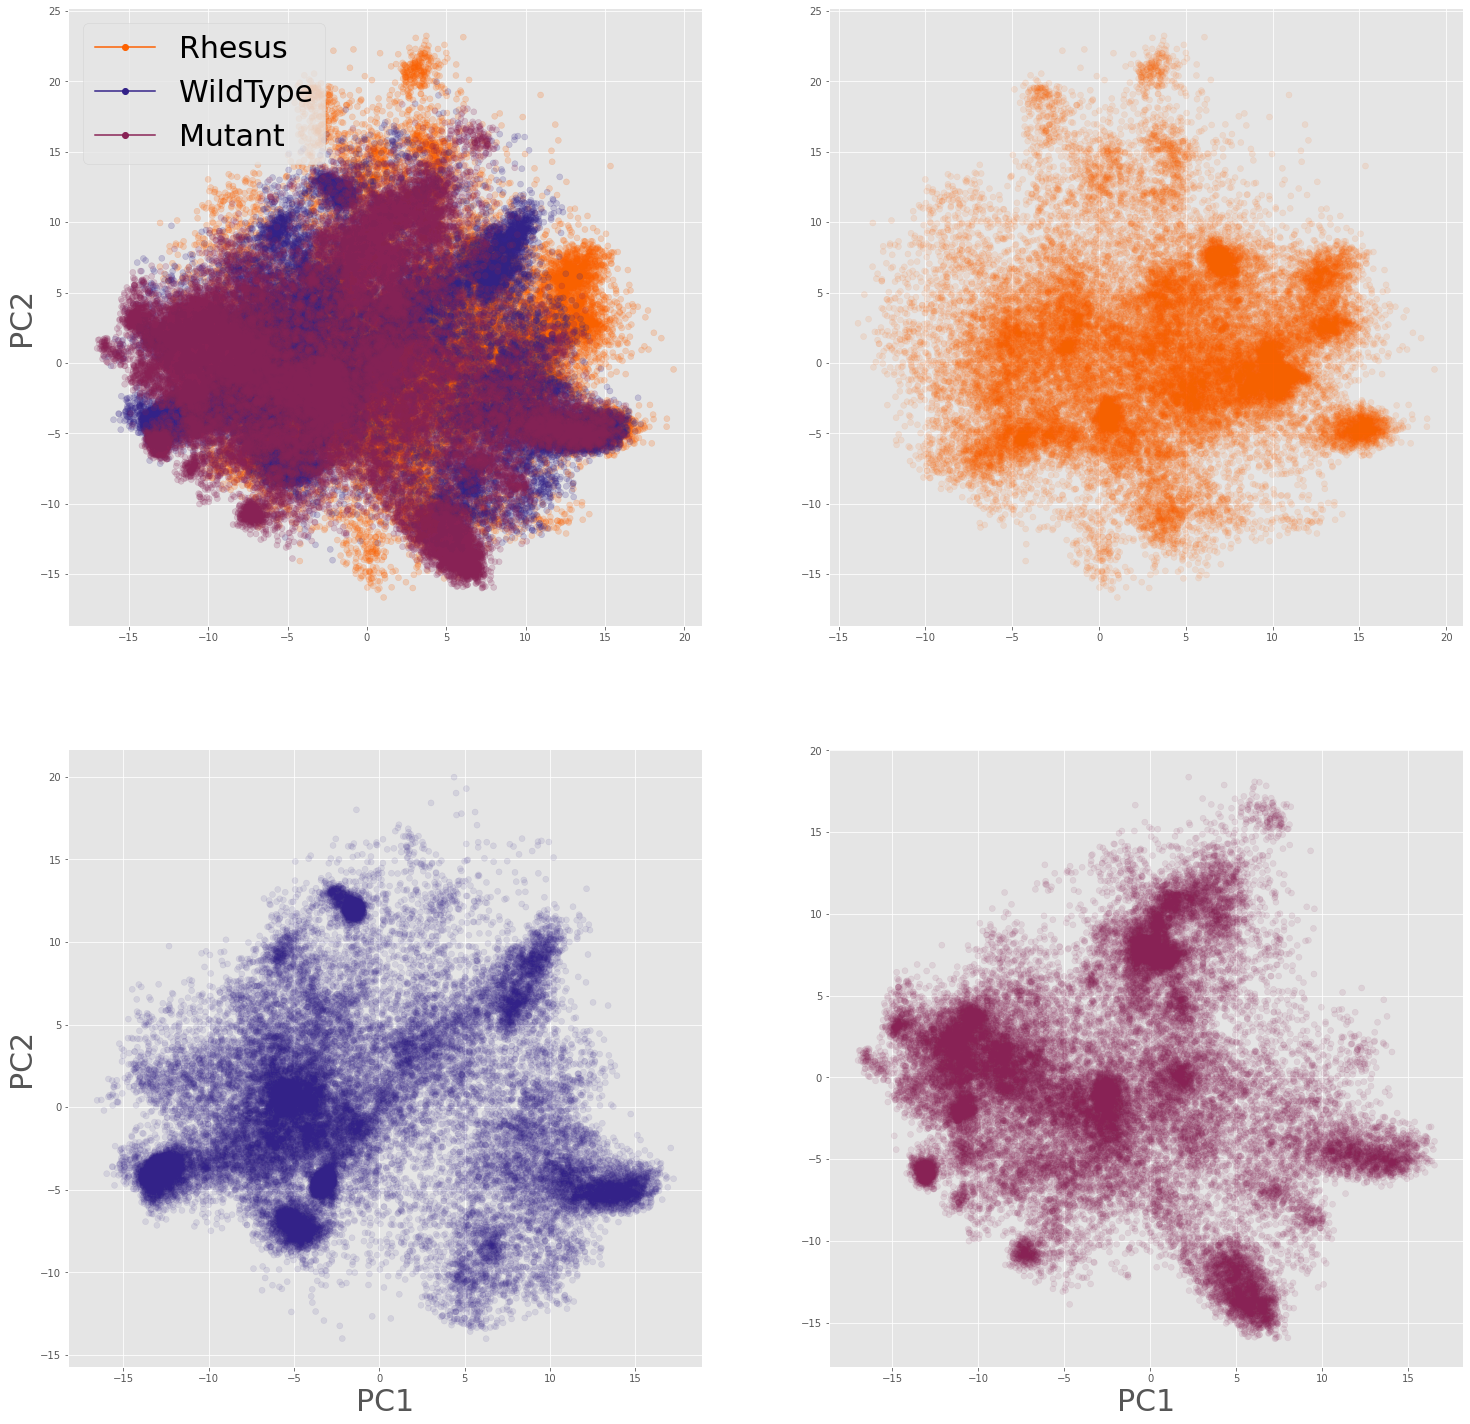

In [19]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*v1_pcaPoints,color = v1_pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-18,25)
#xlim(-18,21)
#xticks([])
#yticks([])

subplot(2,2,2)
scatter(v1_pcaPoints[0][:int(len(v1_pcaPoints[0])/3)],v1_pcaPoints[1][:int(len(v1_pcaPoints[0])/3)],color = v1_pca_colours[:int(len(v1_pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)

subplot(2,2,3)
scatter(v1_pcaPoints[0][int(len(v1_pcaPoints[0])/3):2*int(len(v1_pcaPoints[0])/3)],v1_pcaPoints[1][int(len(v1_pcaPoints[0])/3):2*int(len(v1_pcaPoints[0])/3)],color = v1_pca_colours[int(len(v1_pcaPoints[0])/3):2*int(len(v1_pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


subplot(2,2,4)
scatter(v1_pcaPoints[0][2*int(len(v1_pcaPoints[0])/3):],v1_pcaPoints[1][2*int(len(v1_pcaPoints[0])/3):],color = v1_pca_colours[2*int(len(v1_pcaPoints[0])/3):],alpha = 0.1)
#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)


Text(0.5, 0, 'PC1')

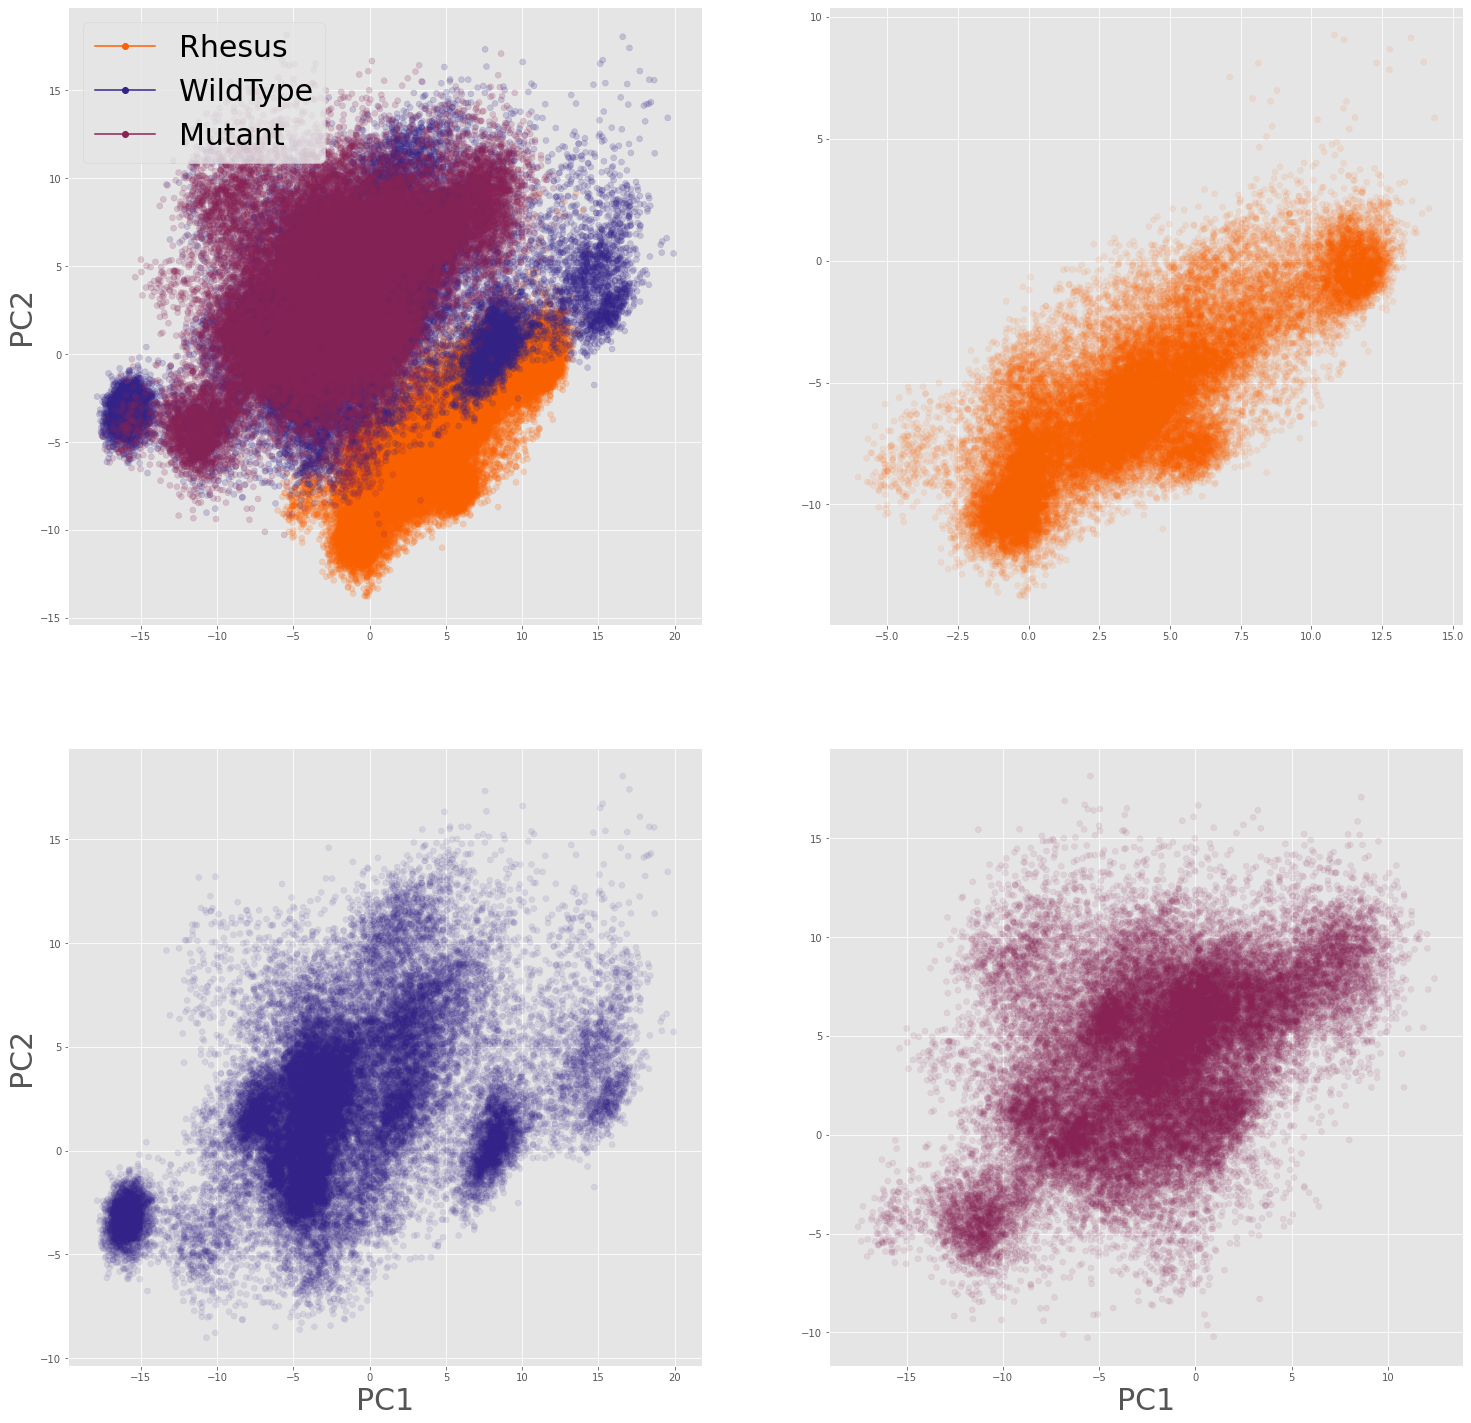

In [20]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*v2_pcaPoints,color = v2_pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-18,25)
#xlim(-18,21)
#xticks([])
#yticks([])

subplot(2,2,2)
scatter(v2_pcaPoints[0][:int(len(v2_pcaPoints[0])/3)],v2_pcaPoints[1][:int(len(v2_pcaPoints[0])/3)],color = v2_pca_colours[:int(len(v2_pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)

subplot(2,2,3)
scatter(v2_pcaPoints[0][int(len(v2_pcaPoints[0])/3):2*int(len(v2_pcaPoints[0])/3)],v2_pcaPoints[1][int(len(v2_pcaPoints[0])/3):2*int(len(v2_pcaPoints[0])/3)],color = v2_pca_colours[int(len(v2_pcaPoints[0])/3):2*int(len(v2_pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


subplot(2,2,4)
scatter(v2_pcaPoints[0][2*int(len(v2_pcaPoints[0])/3):],v2_pcaPoints[1][2*int(len(v2_pcaPoints[0])/3):],color = v2_pca_colours[2*int(len(v2_pcaPoints[0])/3):],alpha = 0.1)
#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)


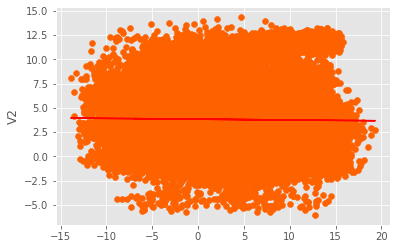

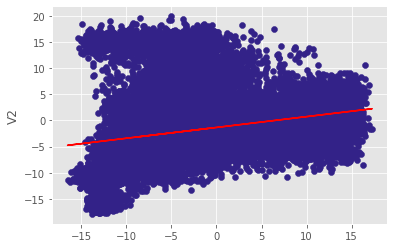

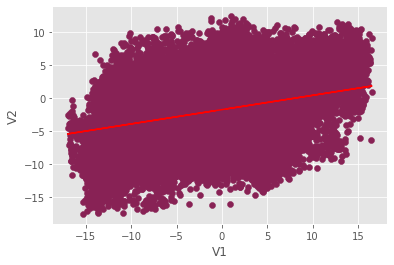

In [47]:
linearfits=[]

linearfits.append(polyfit(array(v1_transformed_dists[0]).T.reshape(2,-1)[0],array(v2_transformed_dists[0]).T.reshape(2,-1)[0],deg = 1))
linearfits.append(polyfit(array(v1_transformed_dists[1]).T.reshape(2,-1)[0],array(v2_transformed_dists[1]).T.reshape(2,-1)[0],deg = 1))
linearfits.append(polyfit(array(v1_transformed_dists[2]).T.reshape(2,-1)[0],array(v2_transformed_dists[2]).T.reshape(2,-1)[0],deg = 1))


scatter(array(v1_transformed_dists[0]).T.reshape(2,-1)[0],array(v2_transformed_dists[0]).T.reshape(2,-1)[0],color = colourScheme[0])
plot(array(v1_transformed_dists[0]).T.reshape(2,-1)[0],linearfits[0][1] + linearfits[0][0]*array(v1_transformed_dists[0]).T.reshape(2,-1)[0],color = 'red')
ylabel("V2")
show()
scatter(array(v1_transformed_dists[1]).T.reshape(2,-1)[0],array(v2_transformed_dists[1]).T.reshape(2,-1)[0],color = colourScheme[1])
plot(array(v1_transformed_dists[1]).T.reshape(2,-1)[0],linearfits[1][1] + linearfits[1][0]*array(v1_transformed_dists[1]).T.reshape(2,-1)[0],color = 'red')
ylabel("V2")
show()
scatter(array(v1_transformed_dists[2]).T.reshape(2,-1)[0],array(v2_transformed_dists[2]).T.reshape(2,-1)[0],color = colourScheme[2])
plot(array(v1_transformed_dists[2]).T.reshape(2,-1)[0],linearfits[2][1] + linearfits[2][0]*array(v1_transformed_dists[2]).T.reshape(2,-1)[0],color = 'red')
ylabel("V2")
xlabel("V1")

show()


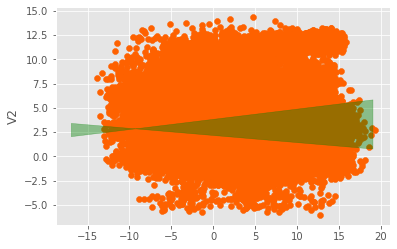

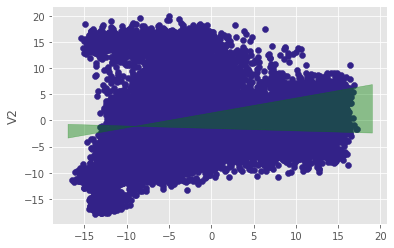

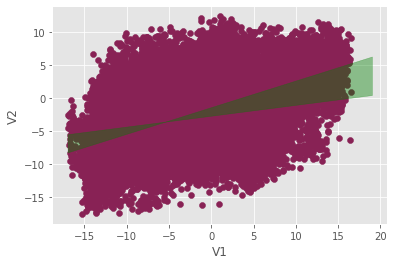

In [114]:
v1_pc1s=array(v1_transformed_dists).T[0].T
v2_pc1s=array(v2_transformed_dists).T[0].T

linearfits=[]


for i in range(len(v1_pc1s)):
    sub=[]
    for j in range(len(v1_pc1s[i])):
        sub.append(polyfit(array(v1_pc1s)[i][j],array(v2_pc1s)[i][j],deg = 1))
        
    linearfits.append(sub)
    

avg_fits = []
sem_fits = []
for i in range(len(linearfits)):
    avg_fits.append(mean(array(linearfits[i]),axis = 0))
    sem_fits.append(scipy.stats.sem(array(linearfits[i]),axis = 0))
    
    
xs = arange(min(v1_pc1s.flatten()),max(v1_pc1s.flatten()))
lines = []
for i in range(len(avg_fits)):
    lines.append(avg_fits[i][1] + avg_fits[i][0]*xs)
    
bottomLines=[]
for i in range(len(avg_fits)):
    bottomLines.append((avg_fits[i][1] - sem_fits[i][1]) + ((avg_fits[i][0]-sem_fits[i][0])*xs))
    
topLines=[]
for i in range(len(avg_fits)):
    topLines.append((avg_fits[i][1] + sem_fits[i][1]) + ((avg_fits[i][0]+sem_fits[i][0])*xs))
    
    

    
    
scatter(array(v1_transformed_dists[0]).T.reshape(2,-1)[0],array(v2_transformed_dists[0]).T.reshape(2,-1)[0],color = colourScheme[0])
ylabel("V2")
fill_between(xs,bottomLines[0],topLines[0],alpha = 0.4,color = 'green')

show()
scatter(array(v1_transformed_dists[1]).T.reshape(2,-1)[0],array(v2_transformed_dists[1]).T.reshape(2,-1)[0],color = colourScheme[1])
ylabel("V2")
fill_between(xs,bottomLines[1],topLines[1],alpha = 0.4,color = 'green')


show()
scatter(array(v1_transformed_dists[2]).T.reshape(2,-1)[0],array(v2_transformed_dists[2]).T.reshape(2,-1)[0],color = colourScheme[2])
ylabel("V2")
xlabel("V1")
fill_between(xs,bottomLines[2],topLines[2],alpha = 0.4,color = 'green')


show()

In [128]:
scipy.stats.pearsonr(v1_pc1s[0].flatten(),v2_pc1s[0].flatten())

(-0.01372164741436524, 0.009218116992337738)

In [127]:
scipy.stats.pearsonr(v1_pc1s[1].flatten(),v2_pc1s[1].flatten())

(0.22477842685817054, 0.0)

In [126]:
scipy.stats.pearsonr(v1_pc1s[2].flatten(),v2_pc1s[2].flatten())

(0.3065500442534017, 0.0)

In [134]:
all_pearsonrs=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(v1_pc1s[i])):
        sub.append(scipy.stats.pearsonr(v1_pc1s[i][j],v2_pc1s[i][j])[0])
    all_pearsonrs.append(sub)
    
avg_pearsonrs=[]
sem_pearsonrs=[]
for i in range(len(all_pearsonrs)):
    avg_pearsonrs.append(mean(all_pearsonrs[i]))
    sem_pearsonrs.append(scipy.stats.sem(all_pearsonrs[i]))
    
for i in range(len(avg_pearsonrs)):
    print(avg_pearsonrs[i],sem_pearsonrs[i])

-0.05032014568271652 0.10303662881059861
0.06835899988829792 0.12906450924066068
0.24175169747055192 0.09778885172670353


-0.05032014568271652 0.10303662881059861
0.06835899988829792 0.12906450924066068
0.24175169747055192 0.09778885172670353
